In [10]:
!pip install scikit-image matplotlib numpy
! apt-get install python3-skimage
print("done")

Defaulting to user installation because normal site-packages is not writeable
/usr/bin/sh: 1: sudo: not found
done


In [6]:
import sys
!{sys.executable} -m pip install scikit-image

Defaulting to user installation because normal site-packages is not writeable


In [7]:
import sys
print(sys.executable)

/usr/local/bin/python3.10


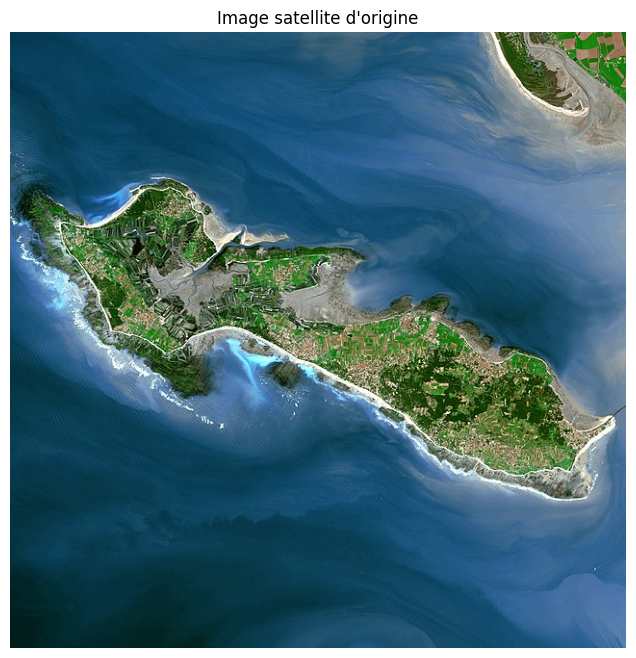

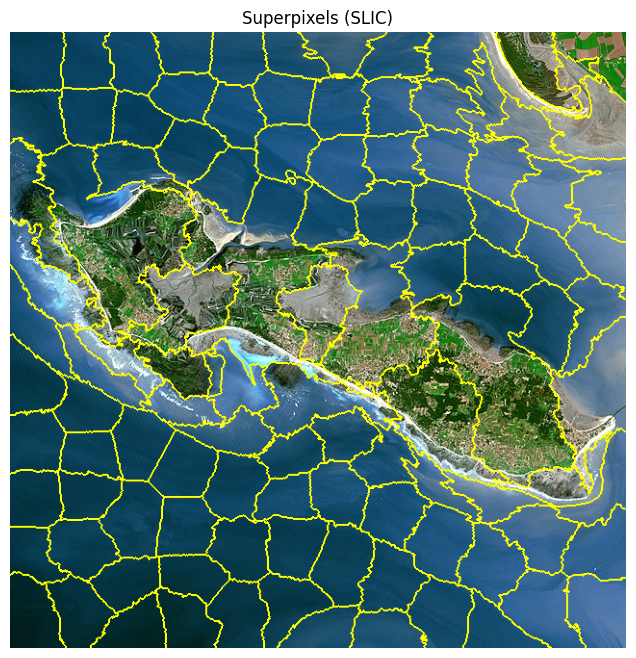

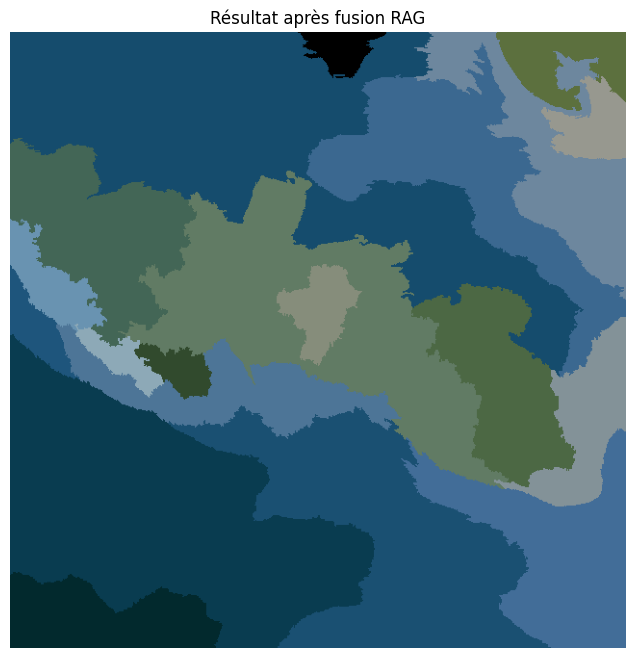

In [60]:
# satellite_rag_segmentation.ipynb

import numpy as np
import matplotlib.pyplot as plt
from skimage import io, segmentation, color
from skimage import graph
from skimage.segmentation import slic, mark_boundaries
from skimage.graph import merge_hierarchical

# 🔹 Étape 1 : Charger une image satellite
image_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/6/64/R%C3%A9_SPOT_1156.jpg/640px-R%C3%A9_SPOT_1156.jpg"
#image_url = "https://www.la-sauvetat-du-dropt.fr/wp-content/uploads/VueSatellite.jpg"
image = io.imread(image_url)
np_image = np.array(image)

plt.figure(figsize=(8, 8))
plt.title("Image satellite d'origine")
plt.imshow(image)
plt.axis("off")
plt.show()

# 🔹 Étape 2 : Sur-segmentation en superpixels
segments = slic(image, n_segments=150, compactness=10, start_label=1)

plt.figure(figsize=(8, 8))
plt.title("Superpixels (SLIC)")
plt.imshow(mark_boundaries(image, segments))
plt.axis("off")
plt.show()

# 🔹 Étape 3 : Construction du RAG
rag = graph.rag_mean_color(image, segments)

# 🔹 Étape 4 : Fusion hiérarchique de régions similaires
import numpy as np

def merge_mean_color(graph, src, dst):
    """
    Met à jour la couleur moyenne d’un nœud lors d’une fusion.
    """
    graph.nodes[dst]['total color'] += graph.nodes[src]['total color']
    graph.nodes[dst]['pixel count'] += graph.nodes[src]['pixel count']
    graph.nodes[dst]['mean color'] = (
        graph.nodes[dst]['total color'] / graph.nodes[dst]['pixel count']
    )
    return {
        'total color': graph.nodes[dst]['total color'],
        'pixel count': graph.nodes[dst]['pixel count'],
        'mean color': graph.nodes[dst]['mean color']
    }

def weight_mean_color(graph, src, dst, n):
    diff = graph.nodes[dst]['mean color'] - graph.nodes[n]['mean color']
    weight = np.linalg.norm(diff)
    return {'weight': weight}  # ✅ doit retourner un dict


# Initialisation des attributs de chaque nœud dans le RAG
for node in rag.nodes:
    mask = segments == node
    region_color = image[mask].mean(axis=0)
    rag.nodes[node]['mean color'] = region_color
    rag.nodes[node]['total color'] = image[mask].sum(axis=0)
    rag.nodes[node]['pixel count'] = mask.sum()


from skimage import graph

labels = merge_hierarchical(
    segments,
    rag,
    thresh=35,
    rag_copy=False,
    in_place_merge=True,
    merge_func=merge_mean_color,
    weight_func=weight_mean_color
)


# 🔹 Étape 5 : Résultat final
out = color.label2rgb(labels, image, kind='avg')

plt.figure(figsize=(8, 8))
plt.title("Résultat après fusion RAG")
plt.imshow(out)
plt.axis("off")
plt.show()


In [9]:
import open_clip

# 3. Charger OpenCLIP
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
tokenizer = open_clip.get_tokenizer('ViT-B-32')

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.10/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [11]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device).eval()

In [67]:
# 4. Définitions des classes possibles
class_names = [
    "ocean",            # mer ouverte
    "beach",            # sable/littoral
    "salt marsh",       # marais salants, lagunes
    "agricultural field",  # champs cultivés
    "forest",           # végétation dense
    "urban area",       # zones bâties, villages
    "harbor"            # zone portuaire
]
#class_names_fr = [
#    "zone urbaine",      # urban area
#    "route",             # road
#    "champ cultivé",     # agricultural field
#    "forêt",             # forest
#    #"rivière",           # river
#    "pont",              # bridge
#    "prairie"            # grassland
#]

class_names_fr = [
    "eau",      
    "plage",        
    "végétation dense", 
    "agriculture",  
    "forêt",
    "zones bâties, village", 
]

text_tokens = tokenizer(class_names_fr).to(device)
with torch.no_grad():
    text_features = model.encode_text(text_tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)
print("done")

done


In [68]:
from PIL import Image

# 5. Extraire et labelliser chaque région
output_labels = {}
for region_id in np.unique(segments):
    mask = segments == region_id
    ys, xs = np.where(mask)

    # Bounding box de la région
    min_x, max_x = xs.min(), xs.max()
    min_y, max_y = ys.min(), ys.max()

    region_crop = image[min_y:max_y+1, min_x:max_x+1]
    pil_region = Image.fromarray(region_crop)
    image_input = preprocess(pil_region).unsqueeze(0).to(device)

    with torch.no_grad():
        image_feature = model.encode_image(image_input)
        image_feature /= image_feature.norm(dim=-1, keepdim=True)

        # Similarité avec les labels texte
        similarity = (image_feature @ text_features.T).squeeze(0)
        label_id = similarity.argmax().item()
        label = class_names_fr[label_id]
        output_labels[region_id] = label

print("Labels prédits pour chaque région :")
print(output_labels)


Labels prédits pour chaque région :
{np.int64(1): 'eau', np.int64(2): 'eau', np.int64(3): 'eau', np.int64(4): 'eau', np.int64(5): 'plage', np.int64(6): 'plage', np.int64(7): 'eau', np.int64(8): 'plage', np.int64(9): 'plage', np.int64(10): 'agriculture', np.int64(11): 'agriculture', np.int64(12): 'plage', np.int64(13): 'plage', np.int64(14): 'eau', np.int64(15): 'plage', np.int64(16): 'plage', np.int64(17): 'agriculture', np.int64(18): 'eau', np.int64(19): 'plage', np.int64(20): 'plage', np.int64(21): 'eau', np.int64(22): 'eau', np.int64(23): 'eau', np.int64(24): 'plage', np.int64(25): 'eau', np.int64(26): 'plage', np.int64(27): 'plage', np.int64(28): 'plage', np.int64(29): 'eau', np.int64(30): 'forêt', np.int64(31): 'plage', np.int64(32): 'agriculture', np.int64(33): 'plage', np.int64(34): 'plage', np.int64(35): 'eau', np.int64(36): 'zones bâties, village', np.int64(37): 'eau', np.int64(38): 'plage', np.int64(39): 'plage', np.int64(40): 'eau', np.int64(41): 'plage', np.int64(42): 'eau'

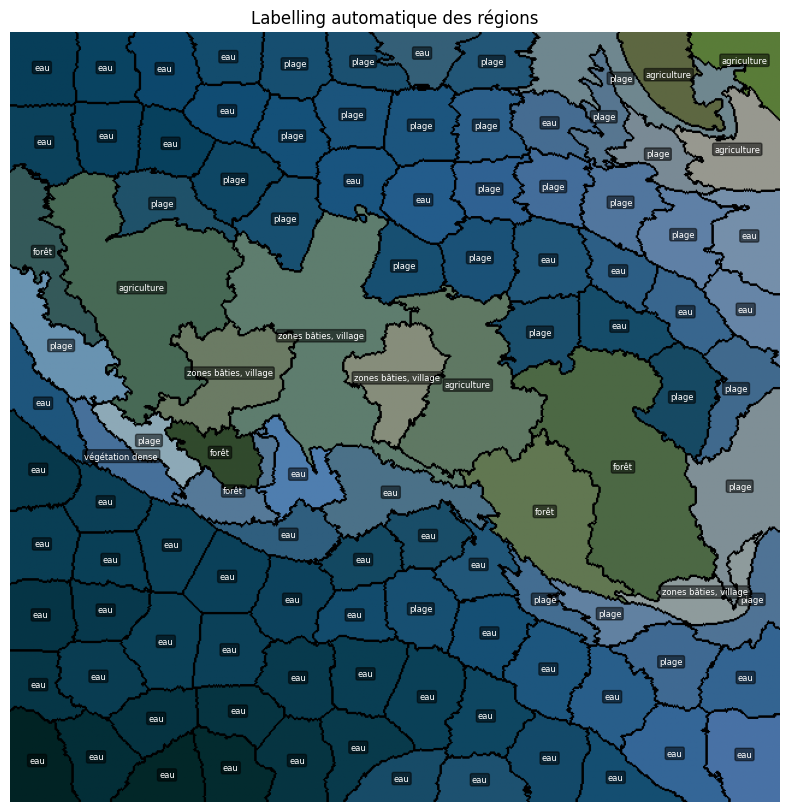

In [69]:
# 6. Affichage visuel des labels (optionnel)
from skimage.segmentation import mark_boundaries

label_overlay = color.label2rgb(segments, image, kind='avg')
plt.figure(figsize=(10, 10))
plt.imshow(mark_boundaries(label_overlay, segments, color=(0, 0, 0)))
for region_id in output_labels:
    mask = segments == region_id
    ys, xs = np.where(mask)
    y, x = int(ys.mean()), int(xs.mean())
    plt.text(x, y, output_labels[region_id], color='white', fontsize=6, ha='center', va='center', bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.2'))
plt.title("Labelling automatique des régions")
plt.axis("off")
plt.show()

In [70]:
# 6. Calcul du label dominant par superpixel
label_map = np.zeros(segments.shape, dtype=int)

for seg_val in np.unique(segments):
    mask = segments == seg_val
    x, y = np.where(mask)
    crop = np_image[x.min():x.max(), y.min():y.max()]
    pil_crop = Image.fromarray(crop).resize((224, 224))
    image_input = preprocess(pil_crop).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = model.encode_image(image_input)
        image_features /= image_features.norm(dim=-1, keepdim=True)
    similarity = (image_features @ text_features.T).squeeze(0)
    label = similarity.argmax().item()
    label_map[mask] = label

In [71]:
# label_map : matrice (H, W) avec int = indice de classe

total_pixels = label_map.size
counts = np.bincount(label_map.flatten())

percentages = 100 * counts / total_pixels

# Pour chaque classe, afficher le pourcentage
for idx, pct in enumerate(percentages):
    label_name = class_names_fr[idx]
    print(f"{label_name}: {pct:.2f}%")

eau: 50.67%
plage: 22.74%
végétation dense: 4.41%
agriculture: 2.79%
forêt: 7.24%
zones bâties, village: 12.15%


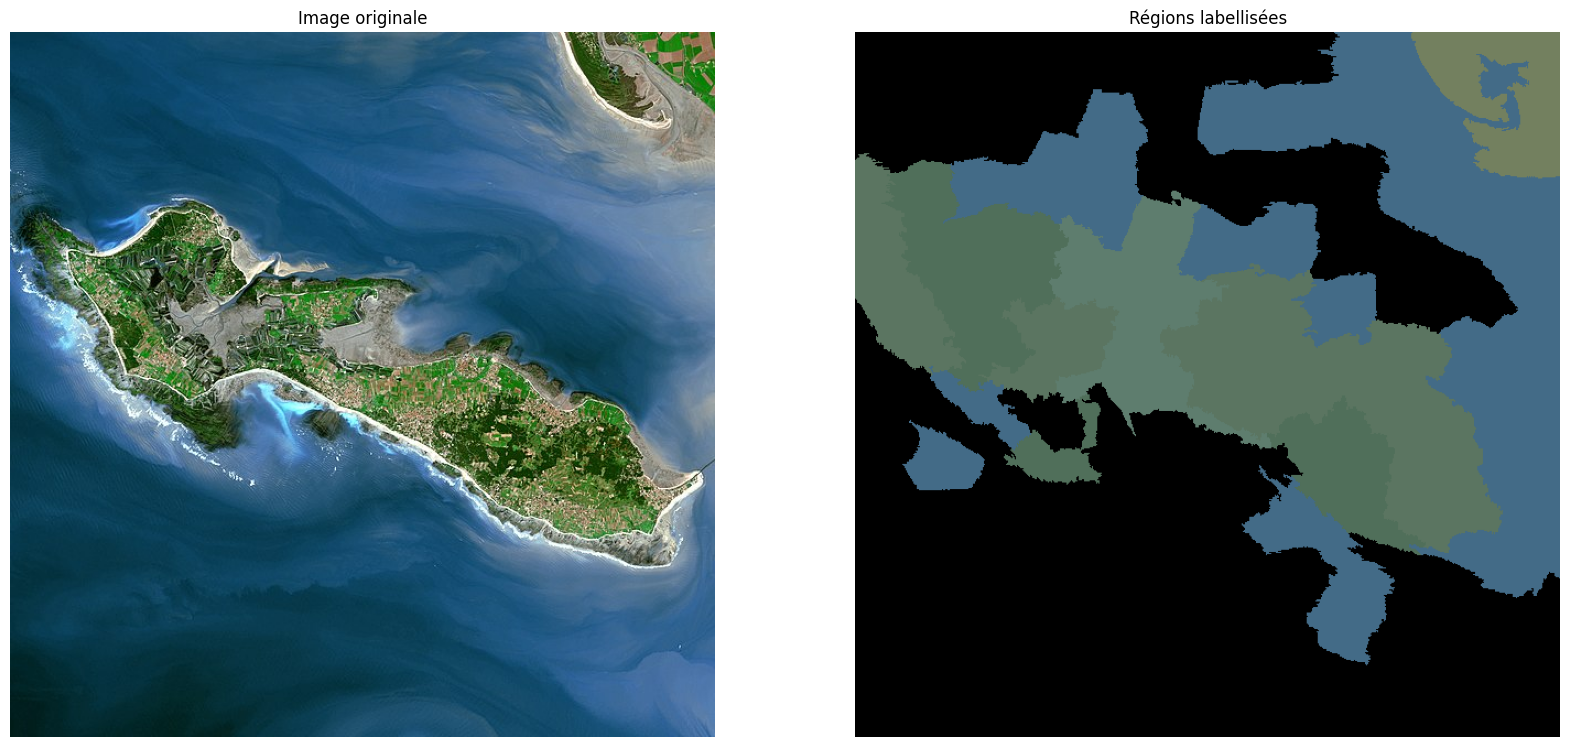

In [72]:
plt.figure(figsize=(20,20))
plt.subplot(1, 2, 1)
plt.imshow(np_image)
plt.title("Image originale")
plt.axis("off")

plt.subplot(1, 2, 2)
colored = color.label2rgb(label_map, np_image, kind='avg')
plt.imshow(colored)
plt.title("Régions labellisées")
plt.axis("off")
plt.show()

In [73]:
# 8. Génération d'une description globale (Prompt + Ollama Mistral)
import subprocess
import json

#Construction du prompt
#classes_detectees = list(set(label_map.flatten()))
#labels_detectes = [class_names_fr[i] for i in classes_detectees]
#prompt = f"Tu observes une image satellite. Voici les types de zones détectées automatiquement : {', '.join(labels_detectes)}. Donne une description globale de la scène."

description_labels = ", ".join(
    f"{class_names_fr[i]} ({percentages[i]:.1f}%)"
    for i in range(len(class_names_fr))
    if percentages[i] > 0
)

prompt = f"""Tu observes une image satellite avec les zones suivantes : {description_labels}.
Peux-tu faire une description détaillée de cette scène ?"""

print("\nPrompt envoyé à Mistral :\n", prompt)


Prompt envoyé à Mistral :
 Tu observes une image satellite avec les zones suivantes : eau (50.7%), plage (22.7%), végétation dense (4.4%), agriculture (2.8%), forêt (7.2%), zones bâties, village (12.1%).
Peux-tu faire une description détaillée de cette scène ?


In [74]:
# Envoi du prompt au LLM
import requests

url = "http://host.docker.internal:11435/v1/chat/completions"  # adapte si besoin
headers = {
    "Content-Type": "application/json"
}
data = {
    "model": "mistral",
    "messages": [{"role": "user", "content": prompt}]
}

response = requests.post(url, json=data, headers=headers)
print("\nRéponse du modèle :\n")
print(response.json())


#print("\nPrompt envoyé à Mistral :\n", prompt)
#print("\nRéponse du modèle :\n")
#subprocess.run(ollama_cmd)


Réponse du modèle :

{'id': 'chatcmpl-149', 'object': 'chat.completion', 'created': 1754049356, 'model': 'mistral', 'system_fingerprint': 'fp_ollama', 'choices': [{'index': 0, 'message': {'role': 'assistant', 'content': " Ces données indiquent que la majorité de l'image satellite montre des zones d'eau, qui couvrent approximativement 50,7% de son aire totale. Cette zone pourrait être constituée par un océan ou une grande rivière.\n\nLa seconde zone la plus importante est constituée par une plage, qui représente environ 22,7% de l'image satellite. La présence de plages peut indiquer qu'une partie importante du littoral est visible sur cette image.\n\nIl y a aussi des zones verdoyantes, ce qui indique un développement dense de végétation (4,4% de l'image). Peut-être s'agit-il d'un environnement forestier ou de prairies. On peut également voir des espaces agricoles (2,8%) et des forêts (7,2%), ce qui donne une idée différenciée de la répartition des écosystèmes sur cette région.\n\nDe ma

## Test ADE20K 

In [79]:
!pip install transformers
print("done")

Defaulting to user installation because normal site-packages is not writeable
done


In [80]:
from transformers import SegformerForSemanticSegmentation, SegformerFeatureExtractor
import torch
from PIL import Image
import requests
import numpy as np
import matplotlib.pyplot as plt

# Charger image satellite
url = "https://upload.wikimedia.org/wikipedia/commons/thumb/6/64/R%C3%A9_SPOT_1156.jpg/640px-R%C3%A9_SPOT_1156..jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB").resize((512,512))

# Charger modèle SegFormer ADE20K (plus adapté que COCO pour segmentation)
model_name = "nvidia/segformer-b0-finetuned-ade-512-512"
feature_extractor = SegformerFeatureExtractor.from_pretrained(model_name)
model = SegformerForSemanticSegmentation.from_pretrained(model_name)

# Préparer l’image
inputs = feature_extractor(images=image, return_tensors="pt")

# Inférence
with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
pred = torch.argmax(logits.squeeze(), dim=0).detach().cpu().numpy()

# Palette ADE20K (extrait complet ici, 150 classes)
palette = [
    (120, 120, 120), (180, 120, 120), (6, 230, 230), (80, 50, 50), (4, 200, 3),
    (120, 120, 80), (140, 140, 140), (204, 5, 255), (230, 230, 230), (4, 250, 7),
    (224, 5, 255), (235, 255, 7), (150, 5, 61), (120, 120, 70), (8, 255, 51),
    (255, 6, 82), (143, 255, 140), (204, 255, 4), (255, 51, 7), (204, 70, 3),
    (0, 102, 200), (61, 230, 250), (255, 6, 51), (11, 102, 255), (255, 7, 71),
    (255, 9, 224), (9, 7, 230), (220, 220, 220), (255, 9, 92), (112, 9, 255),
    (8, 255, 214), (7, 255, 224), (255, 184, 6), (10, 255, 71), (255, 41, 10),
    (7, 255, 255), (224, 255, 8), (102, 8, 255), (255, 61, 6), (255, 194, 7),
    (255, 122, 8), (0, 255, 20), (255, 8, 41), (255, 5, 153), (6, 51, 255),
    (235, 12, 255), (160, 150, 20), (0, 163, 255), (140, 140, 140), (250, 10, 15),
    (20, 255, 0), (31, 255, 0), (255, 31, 0), (255, 224, 0), (153, 255, 0),
    (0, 0, 255), (255, 71, 0), (0, 235, 255), (0, 173, 255), (31, 0, 255),
    (11, 200, 200), (255, 82, 0), (0, 255, 245), (0, 61, 255), (0, 255, 112),
    (0, 255, 133), (255, 0, 0), (255, 163, 0), (255, 102, 0), (194, 255, 0),
    (0, 143, 255), (51, 255, 0), (0, 82, 255), (0, 255, 41), (0, 255, 173),
    (10, 0, 255), (173, 255, 0), (255, 92, 0), (255, 0, 255), (255, 0, 245),
    (255, 0, 102), (255, 173, 0), (255, 0, 20), (255, 184, 184), (0, 31, 255),
    (0, 255, 61), (0, 71, 255), (255, 0, 204), (0, 255, 194), (0, 255, 82),
    (0, 10, 255), (0, 112, 255), (51, 0, 255), (0, 194, 255), (0, 122, 255),
    (0, 255, 163), (255, 153, 0), (0, 255, 10), (255, 112, 0), (143, 255, 0),
    (82, 0, 255), (163, 255, 0), (255, 235, 0), (8, 184, 170), (133, 0, 255),
    (0, 255, 92), (184, 0, 255), (255, 0, 31), (0, 184, 255), (0, 214, 255),
    (255, 0, 112), (92, 255, 0), (0, 224, 255), (112, 224, 255), (70, 184, 160),
    (163, 0, 255), (153, 0, 255), (71, 255, 0), (255, 0, 163), (255, 0, 143),
    (0, 255, 235), (133, 255, 0), (255, 214, 0), (25, 194, 194), (102, 255, 0),
    (92, 194, 214), (0, 0, 0)
]

# Noms simplifiés classes ADE20K (extrait)
class_names = [
    "wall", "building", "sky", "floor", "tree", "ceiling", "road", "bed",
    "windowpane", "grass", "cabinet", "sidewalk", "person", "earth", "door",
    "table", "mountain", "plant", "curtain", "chair", "car", "water", "painting",
    "sofa", "shelf", "house", "sea", "mirror", "rug", "field", "armchair",
    "seat", "fence", "desk", "rock", "wardrobe", "lamp", "bathtub", "railing",
    "cushion", "base", "box", "column", "signboard", "chest of drawers",
    "counter", "sand", "sink", "skyscraper", "fireplace", "refrigerator",
    "grandstand", "path", "stairs", "runway", "case", "pool table", "pillow",
    "screen door", "stairway", "river", "bridge", "bookcase", "blind", "coffee table",
    "toilet", "flower", "book", "hill", "bench", "countertop", "stove",
    "palm", "kitchen island", "computer", "swivel chair", "boat", "bar",
    "arcade machine", "hovel", "bus", "towel", "light", "truck", "tower",
    "chandelier", "awning", "streetlight", "booth", "television receiver",
    "airplane", "dirt track", "apparel", "pole", "land", "bannister",
    "escalator", "ottoman", "bottle", "buffet", "poster", "stage", "van",
    "ship", "fountain", "conveyer belt", "canopy", "washer", "plaything",
    "swimming pool", "stool", "barrel", "basket", "waterfall", "tent",
    "bag", "minibike", "cradle", "oven", "ball", "food", "step", "tank",
    "trade name", "microwave", "pot", "animal", "bicycle", "lake", "dishwasher",
    "screen", "blanket", "sculpture", "hood", "sconce", "vase", "traffic light",
    "tray", "ashcan", "fan", "pier", "crt screen", "plate", "monitor", "bulletin board",
    "shower", "radiator", "glass", "clock", "flag"
]


# Colorisation
seg_color = np.zeros((pred.shape[0], pred.shape[1], 3), dtype=np.uint8)
for idx, color in enumerate(palette):
    seg_color[pred == idx] = color

# Affichage
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Image Satellite")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(seg_color)
plt.title("Segmentation SegFormer ADE20K")
plt.axis("off")
plt.show()


ModuleNotFoundError: No module named 'transformers'